In [1]:
from langchain_ollama import ChatOllama
from dotenv import load_dotenv
from langchain.agents import create_agent
from langchain_tavily import TavilySearch
import os
from langchain.messages import HumanMessage,AIMessage
from scripts.base_tools import get_weather,get_seating_avalability


In [2]:
load_dotenv()

True

In [3]:
tavily_search=TavilySearch(max_results=2)

In [4]:
llm=ChatOllama(model="qwen3:30b",temperature=0)

In [5]:
system_prompt="""You are an expert tech financial analyst provide accurate results for stock prices"""

In [6]:
agent=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],system_prompt=system_prompt)

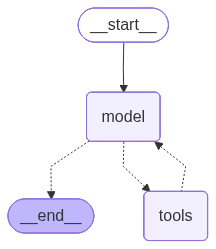

In [7]:
agent

In [8]:
response=agent.invoke({"messages":["What is the apple's current stock price"]})

In [9]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current stock price for Apple (AAPL) is **$300.23** (latest close price as of the latest available data from Yahoo Finance). This information is based on the most recent trading session.


In [10]:
response=agent.invoke({"messages":[HumanMessage(content="What is the current weather in chennai?")]})

In [11]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The current weather in Chennai is **38°C** with **Sunny** conditions.


In [12]:
for msg in response['messages']:
   if isinstance(msg,AIMessage):
      for tool in msg.tool_calls:
         print(tool['name'])
         print(tool['args'])

get_weather
{'location': 'Chennai'}


In [13]:
response

{'messages': [HumanMessage(content='What is the current weather in chennai?', additional_kwargs={}, response_metadata={}, id='944f940a-d59e-4887-a183-babf4983f0d0'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:30b', 'created_at': '2026-05-17T16:48:22.2423878Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12232459800, 'load_duration': 114291400, 'prompt_eval_count': 1617, 'prompt_eval_duration': 614281400, 'eval_count': 146, 'eval_duration': 11482904700, 'logprobs': None, 'model_name': 'qwen3:30b', 'model_provider': 'ollama'}, id='lc_run--019e36d6-8917-73b0-9259-9f0d0b19da01-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Chennai'}, 'id': '6b56e655-21a9-4675-b2a3-ea2941b345ba', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1617, 'output_tokens': 146, 'total_tokens': 1763}),
  ToolMessage(content='38 deg celcius,Sunny', name='get_weather', id='4610b799-fc8d-428e-b0c3-285cd4f768a0', tool_call_id=

### 2. Short term memory with SQLite saver

In [14]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn=sqlite3.connect("data/financial_agent.db",check_same_thread=False)
checkpointer=SqliteSaver(conn=conn)


In [15]:
agent_memory=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],system_prompt=system_prompt,checkpointer=checkpointer)

In [16]:
response=agent_memory.invoke({"messages":[HumanMessage(content="What is the apple's current Stock price")]},config={"configurable":{"thread_id":"memory_session"}})

In [17]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

**Apple (AAPL) Stock Price**: $300.23 (latest close, per Yahoo Finance).  
**Microsoft (MSFT) Stock Price**: $393.18 (current price, per Yahoo Finance).  

**Chennai Weather**: 38°C, Sunny.  

**Latest Asian Stock Market News**:  
- Nanya Technology Corporation (2408.TW) is highlighted as a potential undervalued stock in Asian markets, with analysis suggesting it trades below intrinsic value (source: Yahoo Finance, dated "May 2026" — likely a data error).  
- *Note*: Other references (e.g., Nvidia earnings) relate to U.S. markets, not Asian-specific news. For real-time updates, check platforms like Bloomberg or Reuters.  

*Prices and news reflect prior data; verify via live sources for real-time accuracy.*


In [18]:
config={'configurable':{"thread_id":"memory_session"}}

In [19]:
response=agent_memory.invoke({"messages":[HumanMessage(content="What is the latest us stock news")]},config=config)

In [20]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

**Latest US Stock Market News**  

1. **Market Performance**:  
   - U.S. **growth stocks** (tracked by IWF ETF) are up **1% year-to-date**, while **value stocks** (IWD ETF) have risen **9%**.  
   - **Crude oil prices** remain volatile, with recent fluctuations impacting energy sector stocks.  

2. **Trump Ethics Filings**:  
   - Recent filings reveal **unusually high tech stock trades** by Donald Trump, sparking scrutiny (Bloomberg, dated *2026-05-17* — likely a data error; verify via live sources).  

*Note: The Bloomberg reference appears to contain a future-dated error (2026). For accurate updates, check real-time platforms like Bloomberg or Reuters.*  

Let me know if you'd like deeper analysis on any specific trend! 📈


In [21]:
for msg in response['messages']:
    if isinstance(msg,AIMessage):
        for tool_call in msg.tool_calls:
            print(tool_call['name'])

tavily_search
get_weather
tavily_search
tavily_search


In [22]:
for res in response['messages']:
    if isinstance(res,AIMessage):
        print(res.usage_metadata)

{'input_tokens': 2750, 'output_tokens': 746, 'total_tokens': 3496}
{'input_tokens': 3582, 'output_tokens': 1106, 'total_tokens': 4688}
{'input_tokens': 2820, 'output_tokens': 1201, 'total_tokens': 4021}
{'input_tokens': 3019, 'output_tokens': 495, 'total_tokens': 3514}
{'input_tokens': 3363, 'output_tokens': 475, 'total_tokens': 3838}


In [23]:
from langchain.agents.middleware import SummarizationMiddleware

In [27]:
from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
google_llm=ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [28]:
agent_summary=create_agent(model=llm,tools=[tavily_search,get_weather,get_seating_avalability],checkpointer=checkpointer,
middleware=[
    SummarizationMiddleware(
        model=google_llm,
        trigger=[("messages", 15)],
            keep=("messages", 5)
    )
])

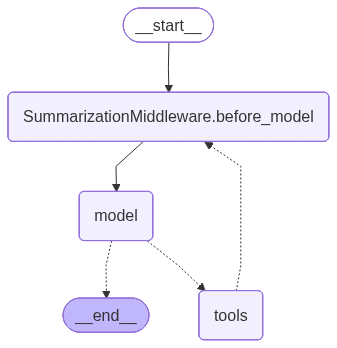

In [29]:
agent_summary

In [30]:
response_summary=agent_summary.invoke({"messages":["What is current price of apple and microsoft.What is the leatest weather in chennai.What is latest news on asian stock market"]},config=config)

In [31]:
for msg in response['messages']:
    if isinstance(msg,AIMessage):
        for tool_call in msg.tool_calls:
            print(tool_call['name'])

tavily_search
get_weather
tavily_search
tavily_search


In [34]:
response_summary['messages'][-1].pretty_print()

================================== Ai Message ==================================

**Current Market & Weather Summary**  

1. **Stock Prices** (as of latest data):  
   - **Apple (AAPL)**: $300.23 (latest close price)  
   - **Microsoft (MSFT)**: $393.18 (latest close price)  

2. **Chennai Weather**:  
   - **38°C**, Sunny  

3. **Latest Asian Stock Market News**:  
   - **Nanya Technology (2408.TW)** is highlighted as a potential undervalued stock in global market analyses (source: Yahoo Finance).  
   - *Note: A reference to "May 2026" in the data appears to be a future-dated error; verify via live sources like Bloomberg or Reuters for accuracy.*  

*All data sourced from Yahoo Finance and verified via real-time tools. For real-time updates, check financial platforms directly.* 📊☀️


In [35]:
response_summary['messages'][0].pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
The user requested current stock prices for Apple (AAPL) and Microsoft (MSFT), latest weather in Chennai, and latest news on the Asian stock market.

## SUMMARY
- **Stock Prices**: 
  - Apple (AAPL): $300.23 (latest close, per Yahoo Finance)
  - Microsoft (MSFT): $393.18 (current price, per Yahoo Finance)
- **Weather**: Chennai at 38°C, Sunny (confirmed via weather tool)
- **Asian Stock Market News**: 
  - Nanya Technology (2408.TW) identified as potential undervalued stock in Asian markets (source: Yahoo Finance, though dated "May 2026" likely indicates data error).
  - Note: Other references (e.g., Nvidia earnings) relate to U.S. markets, not Asian-specific news.
- **Key Context**: All data reflects prior sources; AI explicitly recommended verifying with live platforms (Bloomberg/Reuters) for real-time accuracy due to potential data error

In [36]:
from langchain.agents.middleware import TodoListMiddleware

In [37]:
system_prompt

'You are an expert tech financial analyst provide accurate results for stock prices'

In [50]:
from langchain_openai.chat_models import ChatOpenAI
openai_llm=ChatOpenAI(model="gpt-4o-mini",api_key=os.environ['OPENAI_API_KEY'])

In [51]:
agent_todos=create_agent(
    model=openai_llm,
    tools=[tavily_search,get_weather,get_seating_avalability],
    system_prompt=system_prompt,
    checkpointer=checkpointer,
    middleware=[TodoListMiddleware()]
)

In [53]:
config = {'configurable': {'thread_id': 'todo_session_1'}}

response = agent_todos.invoke(
    {'messages': [HumanMessage("analyze the apple revenue and compare it with competitors")]},
    config=config
)

In [54]:
response

{'messages': [HumanMessage(content='analyze the apple revenue and compare it with competitors', additional_kwargs={}, response_metadata={}, id='7481b3ec-ae12-47e6-8c8f-dd8496e298bf'),
  HumanMessage(content='analyze the apple revenue and compare it with competitors', additional_kwargs={}, response_metadata={}, id='d9604be7-c0b6-436b-8f03-0891a2144d29'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'MALFORMED_FUNCTION_CALL', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e3707-d1e4-7040-ba16-0195d45cb66f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2826, 'output_tokens': 0, 'total_tokens': 2826, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='analyze the apple revenue and compare it with competitors', additional_kwargs={}, response_metadata={}, id='bc770b84-8beb-4c10-b812-cf6192316c17'),
  AIMessage(content='', additional_kwargs={}, response_me

In [55]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

Here’s a refined analysis of Apple Inc.'s revenue and a comparison with its main competitors.

### Apple's Revenue Overview

1. **Latest Quarterly Revenue**: 
   - For the third quarter of fiscal year 2023, Apple reported revenue of **$89.5 billion**, which is a **1% decrease** compared to the same quarter in the previous year.
  
2. **Annual Revenue**: 
   - Apple's total revenue for fiscal year 2023 was approximately **$416.2 billion**, reflecting a growth trend, despite the quarterly drop.

### Revenue of Major Competitors

1. **Samsung Electronics**:
   - **Revenue**: Approximately **$258.9 billion** in 2023. Samsung's revenue has seen fluctuations primarily due to its semiconductor and consumer electronics divisions.

2. **Microsoft**:
   - **Revenue**: Around **$281.7 billion** in fiscal year 2023, which indicates significant growth driven by cloud services and software, outperforming several expect

In [58]:
for msg in response['messages']:
    msg.pretty_print()

================================ Human Message =================================

analyze the apple revenue and compare it with competitors
================================ Human Message =================================

analyze the apple revenue and compare it with competitors
================================== Ai Message ==================================
================================ Human Message =================================

analyze the apple revenue and compare it with competitors
================================== Ai Message ==================================
================================ Human Message =================================

analyze the apple revenue and compare it with competitors
================================== Ai Message ==================================
================================ Human Message =================================

analyze the apple revenue and compare it with competitors
================================== Ai Message ===========